# Predicting Irrigation Need — Exploratory Data Analysis

**Competition:** [Kaggle Playground Series S6E4](https://kaggle.com/competitions/playground-series-s6e4)  
**Goal:** Predict irrigation need class (Low, Medium, High) from environmental conditions  
**Evaluation Metric:** Balanced Accuracy Score

---

## Notebook Structure
1. Imports & Data Loading
2. Dataset Overview
3. Target Variable Analysis
4. Missing Values
5. Numerical Feature Analysis
6. Categorical Feature Analysis
7. Correlation Analysis (Numerical)
8. Mixed Correlation Analysis (Numerical + Categorical)
9. Key Findings

## 1. Imports & Data Loading

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from dython.nominal import associations

import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

In [24]:
# Adjust paths for local vs Kaggle environment
TRAIN_PATH = '../data/raw/train.csv'  # local
TEST_PATH  = '../data/raw/test.csv'

# TRAIN_PATH = '/kaggle/input/playground-series-s6e4/train.csv'  # Kaggle
# TEST_PATH  = '/kaggle/input/playground-series-s6e4/test.csv'

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')

Train shape: (630000, 21)
Test shape:  (270000, 20)


## 2. Dataset Overview

In [25]:
train_df.sample(5, random_state=42)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
364426,364426,Sandy,4.87,38.18,1.37,0.29,21.43,83.74,2082.14,7.09,...,Cotton,Harvest,Zaid,Rainfed,Groundwater,3.53,No,114.18,East,Low
224752,224752,Loamy,5.89,49.28,1.39,3.11,22.91,44.62,1864.00,10.39,...,Sugarcane,Harvest,Rabi,Sprinkler,Reservoir,1.56,Yes,15.00,West,Low
110423,110423,Sandy,6.44,50.75,1.16,0.24,39.88,68.89,1194.07,9.73,...,Rice,Harvest,Zaid,Drip,Groundwater,13.45,Yes,20.48,East,Low
272555,272555,Silt,4.84,49.17,0.85,2.26,20.94,55.12,2033.44,10.78,...,Sugarcane,Flowering,Rabi,Rainfed,Reservoir,6.04,No,91.53,South,Medium
199651,199651,Sandy,5.82,44.72,0.41,0.81,41.49,41.30,2223.23,9.12,...,Rice,Sowing,Zaid,Sprinkler,Groundwater,13.45,No,70.41,North,Low


In [26]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [27]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,630000.0,314999.500000,181865.479132,0.00,157499.7500,314999.50,472499.25,629999.00
Soil_pH,630000.0,6.482497,0.922504,4.80,5.6900,6.44,7.27,8.20
Soil_Moisture,630000.0,37.304482,16.377082,8.00,23.3400,37.75,51.27,64.99
Organic_Carbon,630000.0,0.922858,0.365808,0.30,0.6100,0.91,1.22,1.60
Electrical_Conductivity,630000.0,1.744605,0.952321,0.10,0.9300,1.74,2.58,3.50
Temperature_C,630000.0,26.998166,8.623621,12.00,19.5175,26.96,34.54,42.00
Humidity,630000.0,61.563180,19.708152,25.00,45.3900,61.65,79.12,94.99
Rainfall_mm,630000.0,1462.207566,612.989738,0.38,954.5700,1467.16,2054.28,2499.69
Sunlight_Hours,630000.0,7.513382,1.999322,4.00,5.7600,7.58,9.25,11.00
Wind_Speed_kmh,630000.0,10.375394,5.689458,0.50,5.2800,10.48,15.43,20.00


In [28]:
num_cols = train_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()

# Remove id and target from feature lists
num_cols = [c for c in num_cols if c not in ['id']]
cat_cols = [c for c in cat_cols if c not in ['Irrigation_Need']]

print(f'Numerical features ({len(num_cols)}): {num_cols}')
print(f'Categorical features ({len(cat_cols)}): {cat_cols}')

Numerical features (11): ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
Categorical features (8): ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


## 3. Target Variable Analysis

In [29]:
print('Unique classes:', train_df['Irrigation_Need'].unique())
print()

class_counts = train_df['Irrigation_Need'].value_counts()
class_pct    = train_df['Irrigation_Need'].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pct.round(2)
})
print(class_summary)

Unique classes: ['Low' 'Medium' 'High']

                  Count  Percentage (%)
Irrigation_Need                        
Low              369917           58.72
Medium           239074           37.95
High              21009            3.33


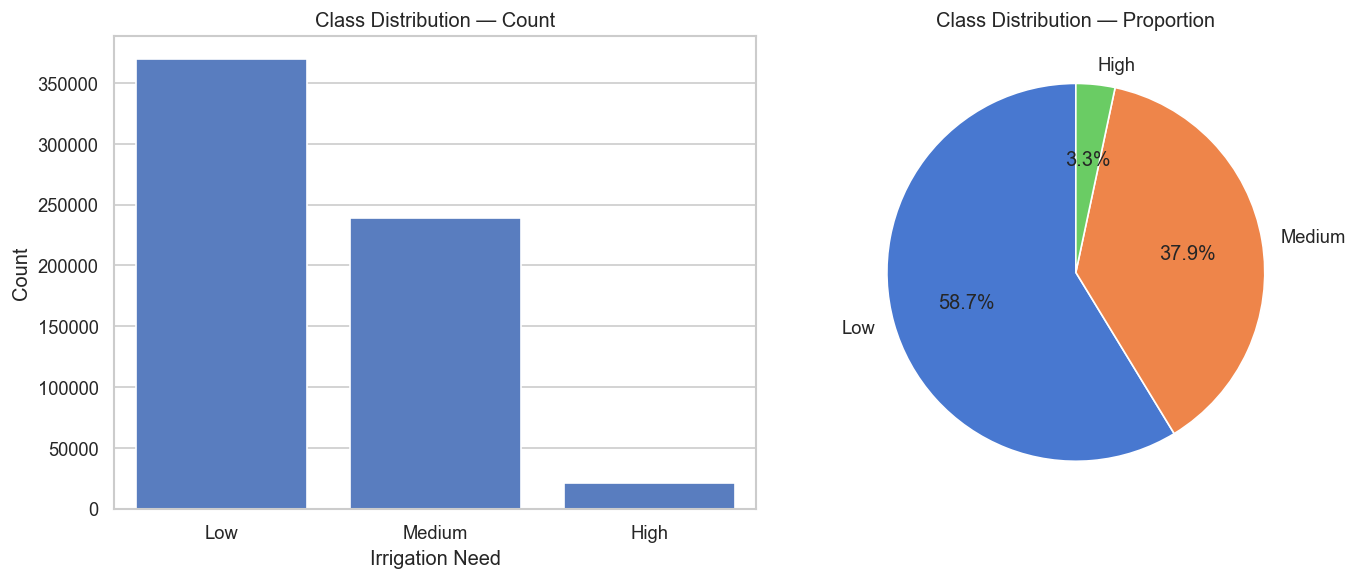

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(data=train_df, x='Irrigation_Need', order=class_counts.index, ax=axes[0])
axes[0].set_title('Class Distribution — Count')
axes[0].set_xlabel('Irrigation Need')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(
    class_counts,
    labels=class_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Class Distribution — Proportion')

plt.tight_layout()
plt.show()

## 4. Missing Values

In [31]:
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
}).query('`Missing Count` > 0')

if missing_df.empty:
    print('No missing values found.')
else:
    print(missing_df)

No missing values found.


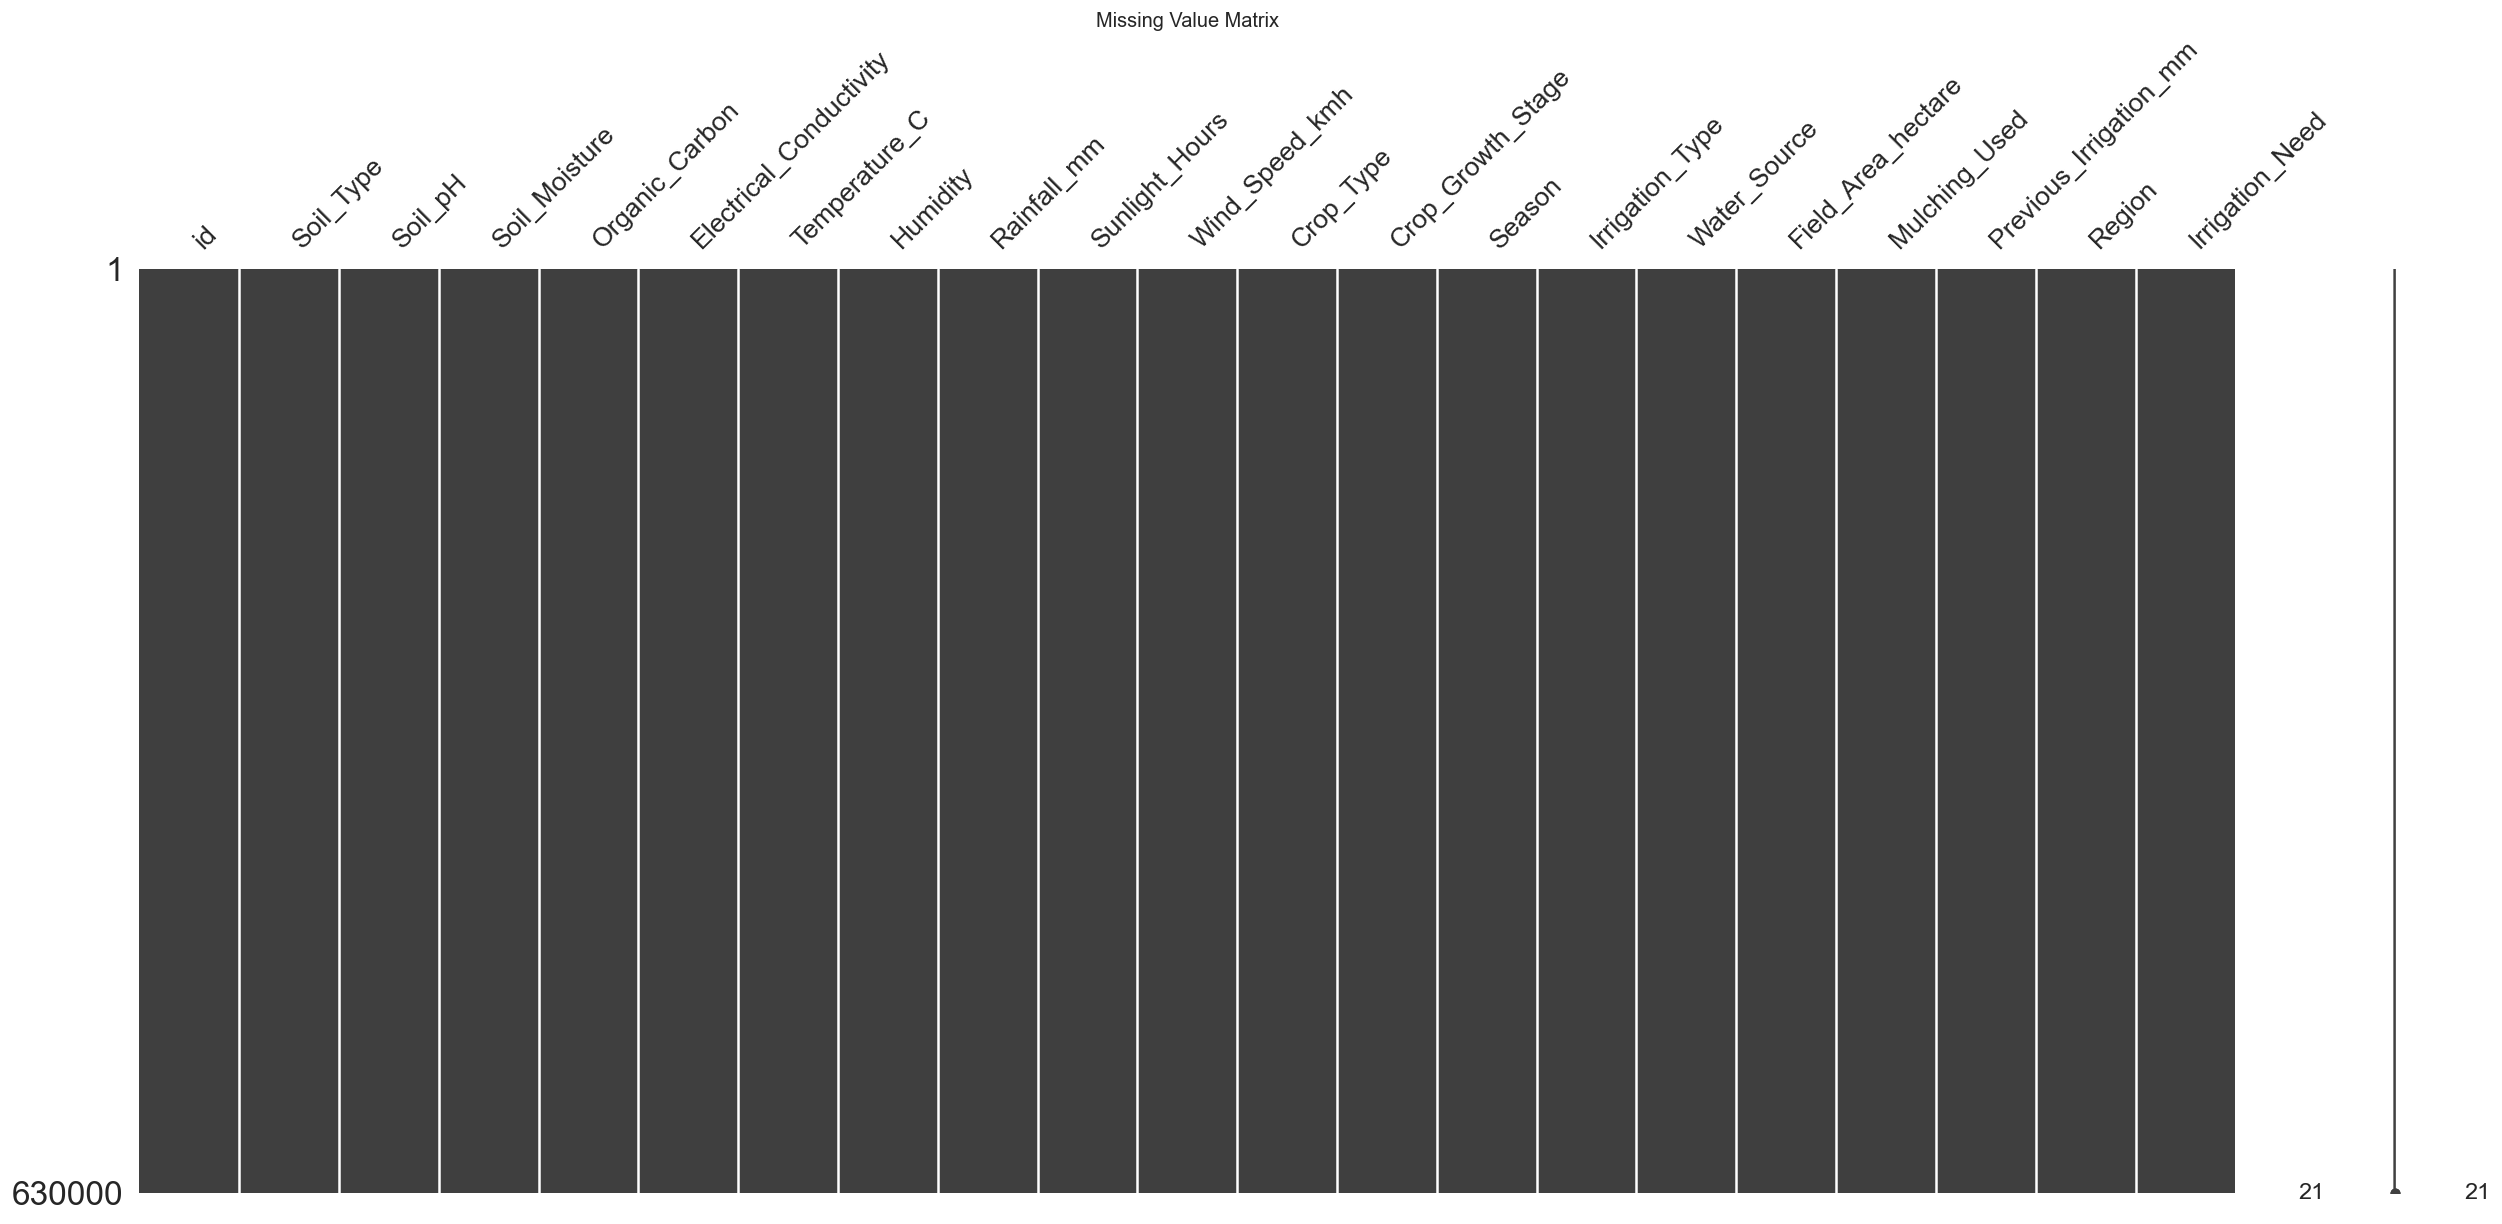

In [32]:
msno.matrix(train_df)
plt.title('Missing Value Matrix')
plt.show()

## 5. Numerical Feature Analysis

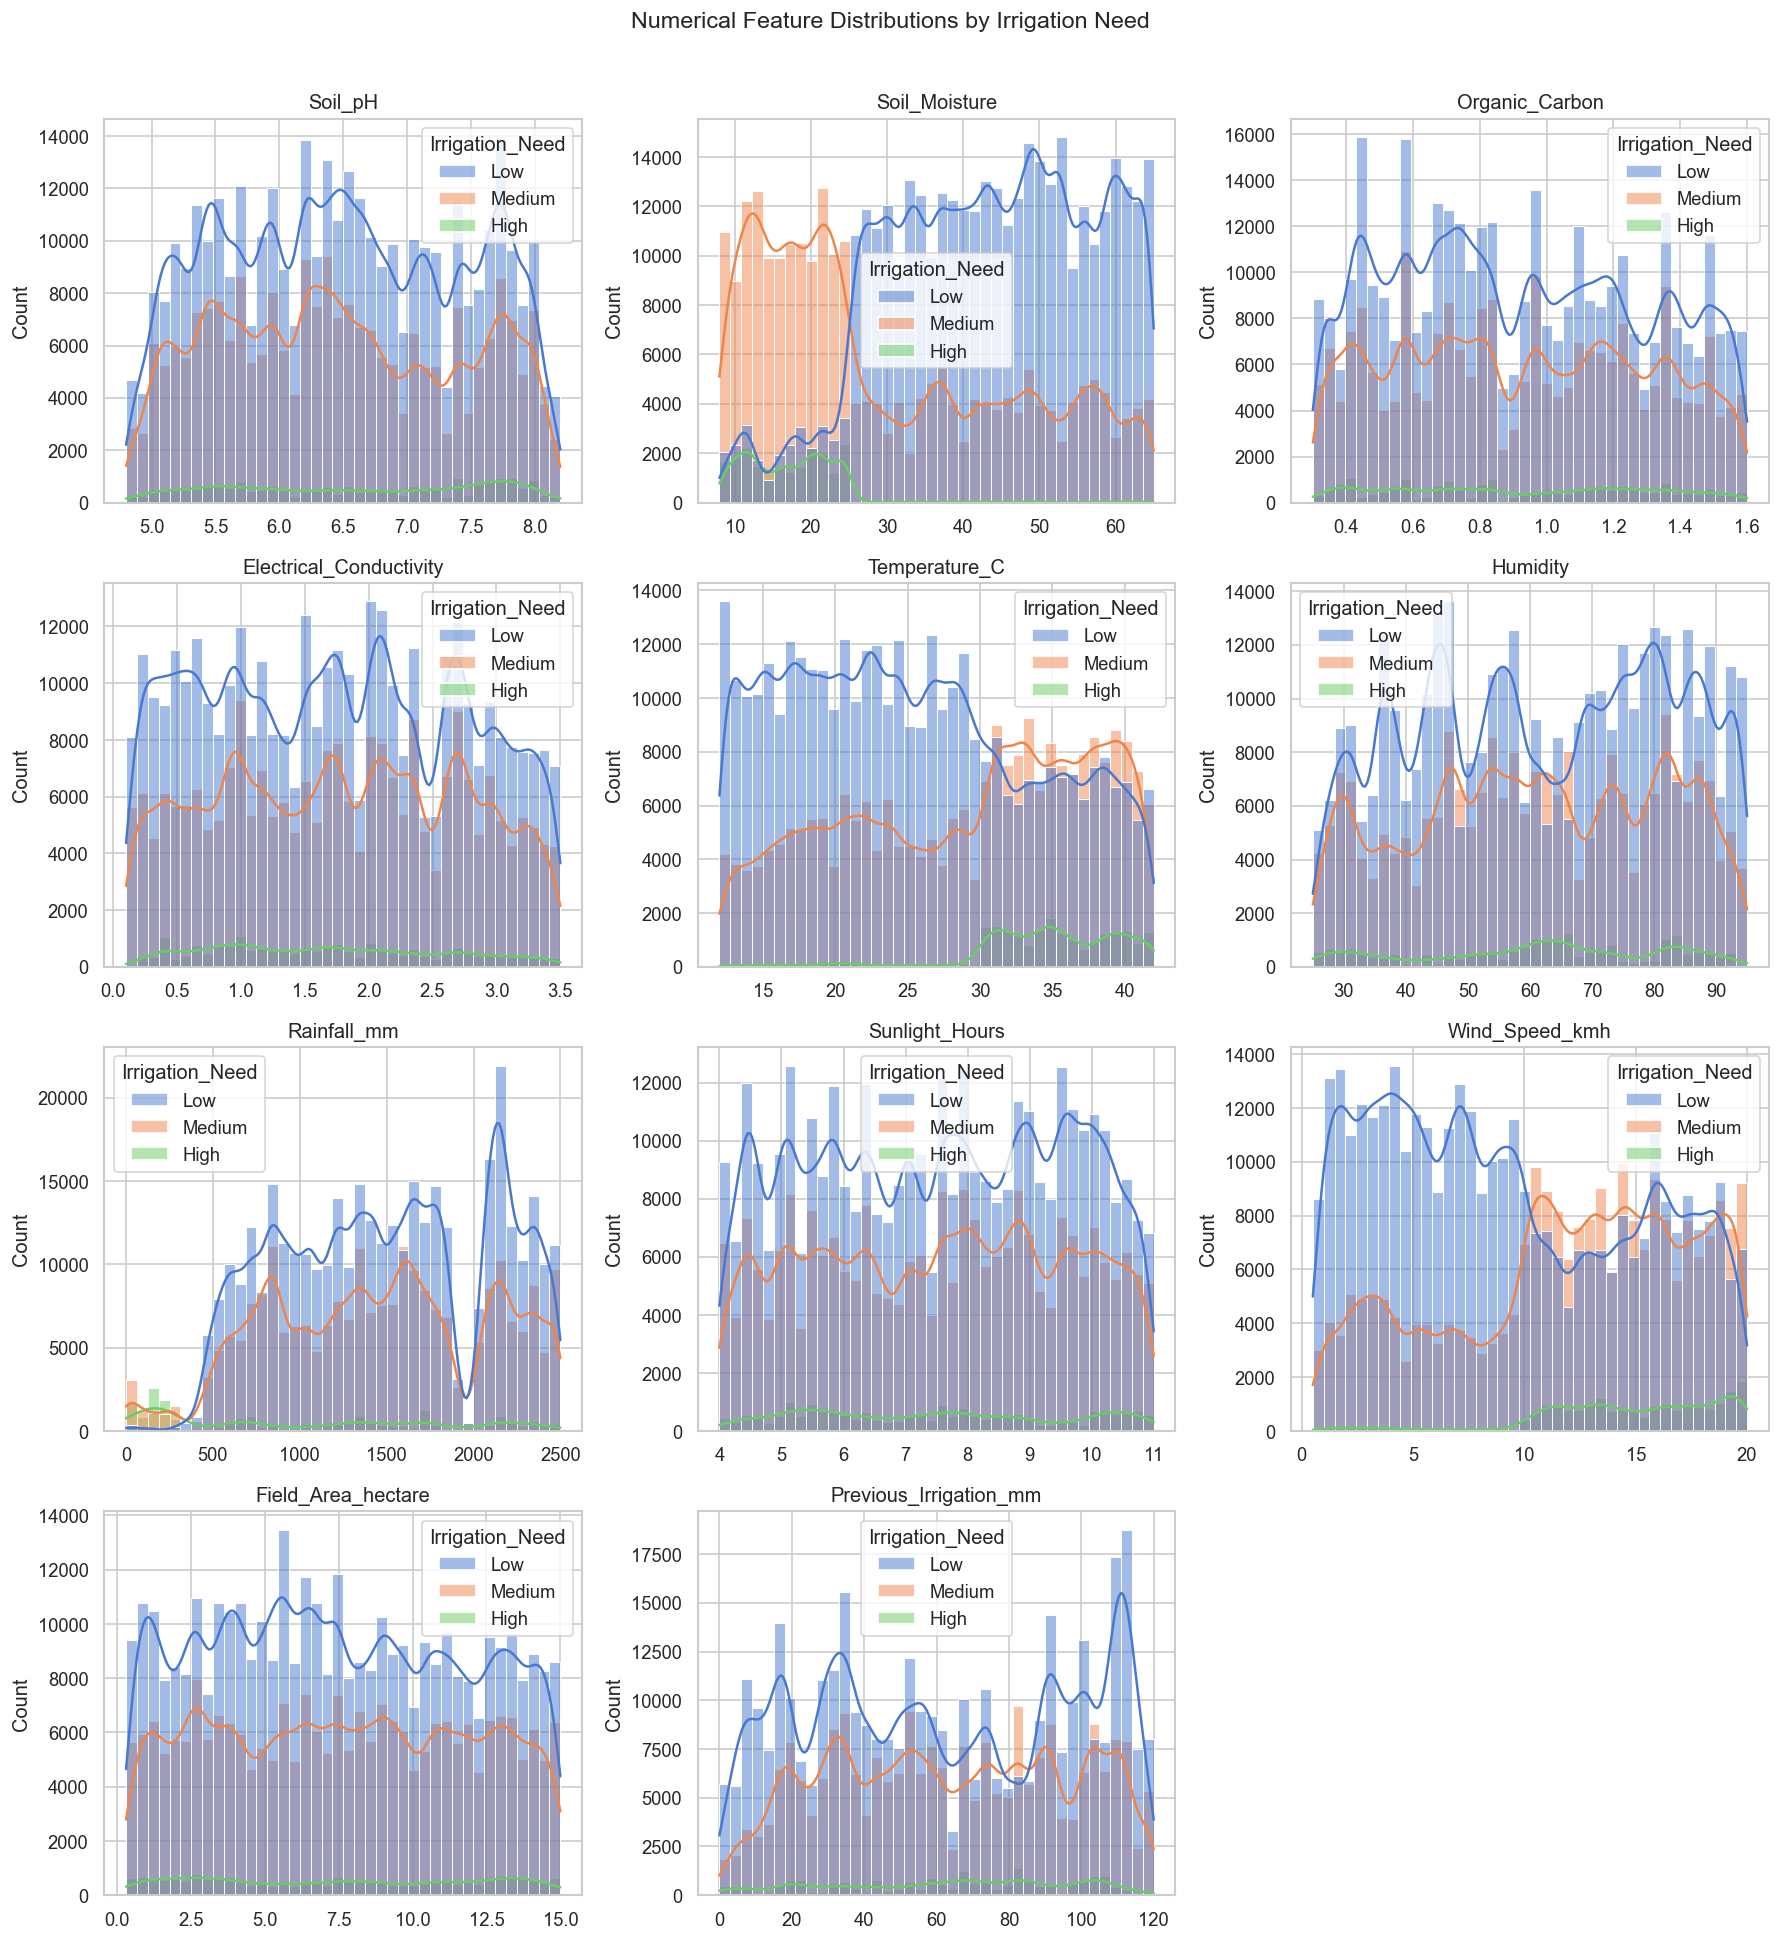

In [33]:
# Distribution of each numerical feature
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=train_df, x=col, hue='Irrigation_Need', kde=True, ax=axes[i], bins=40)
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Irrigation Need', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

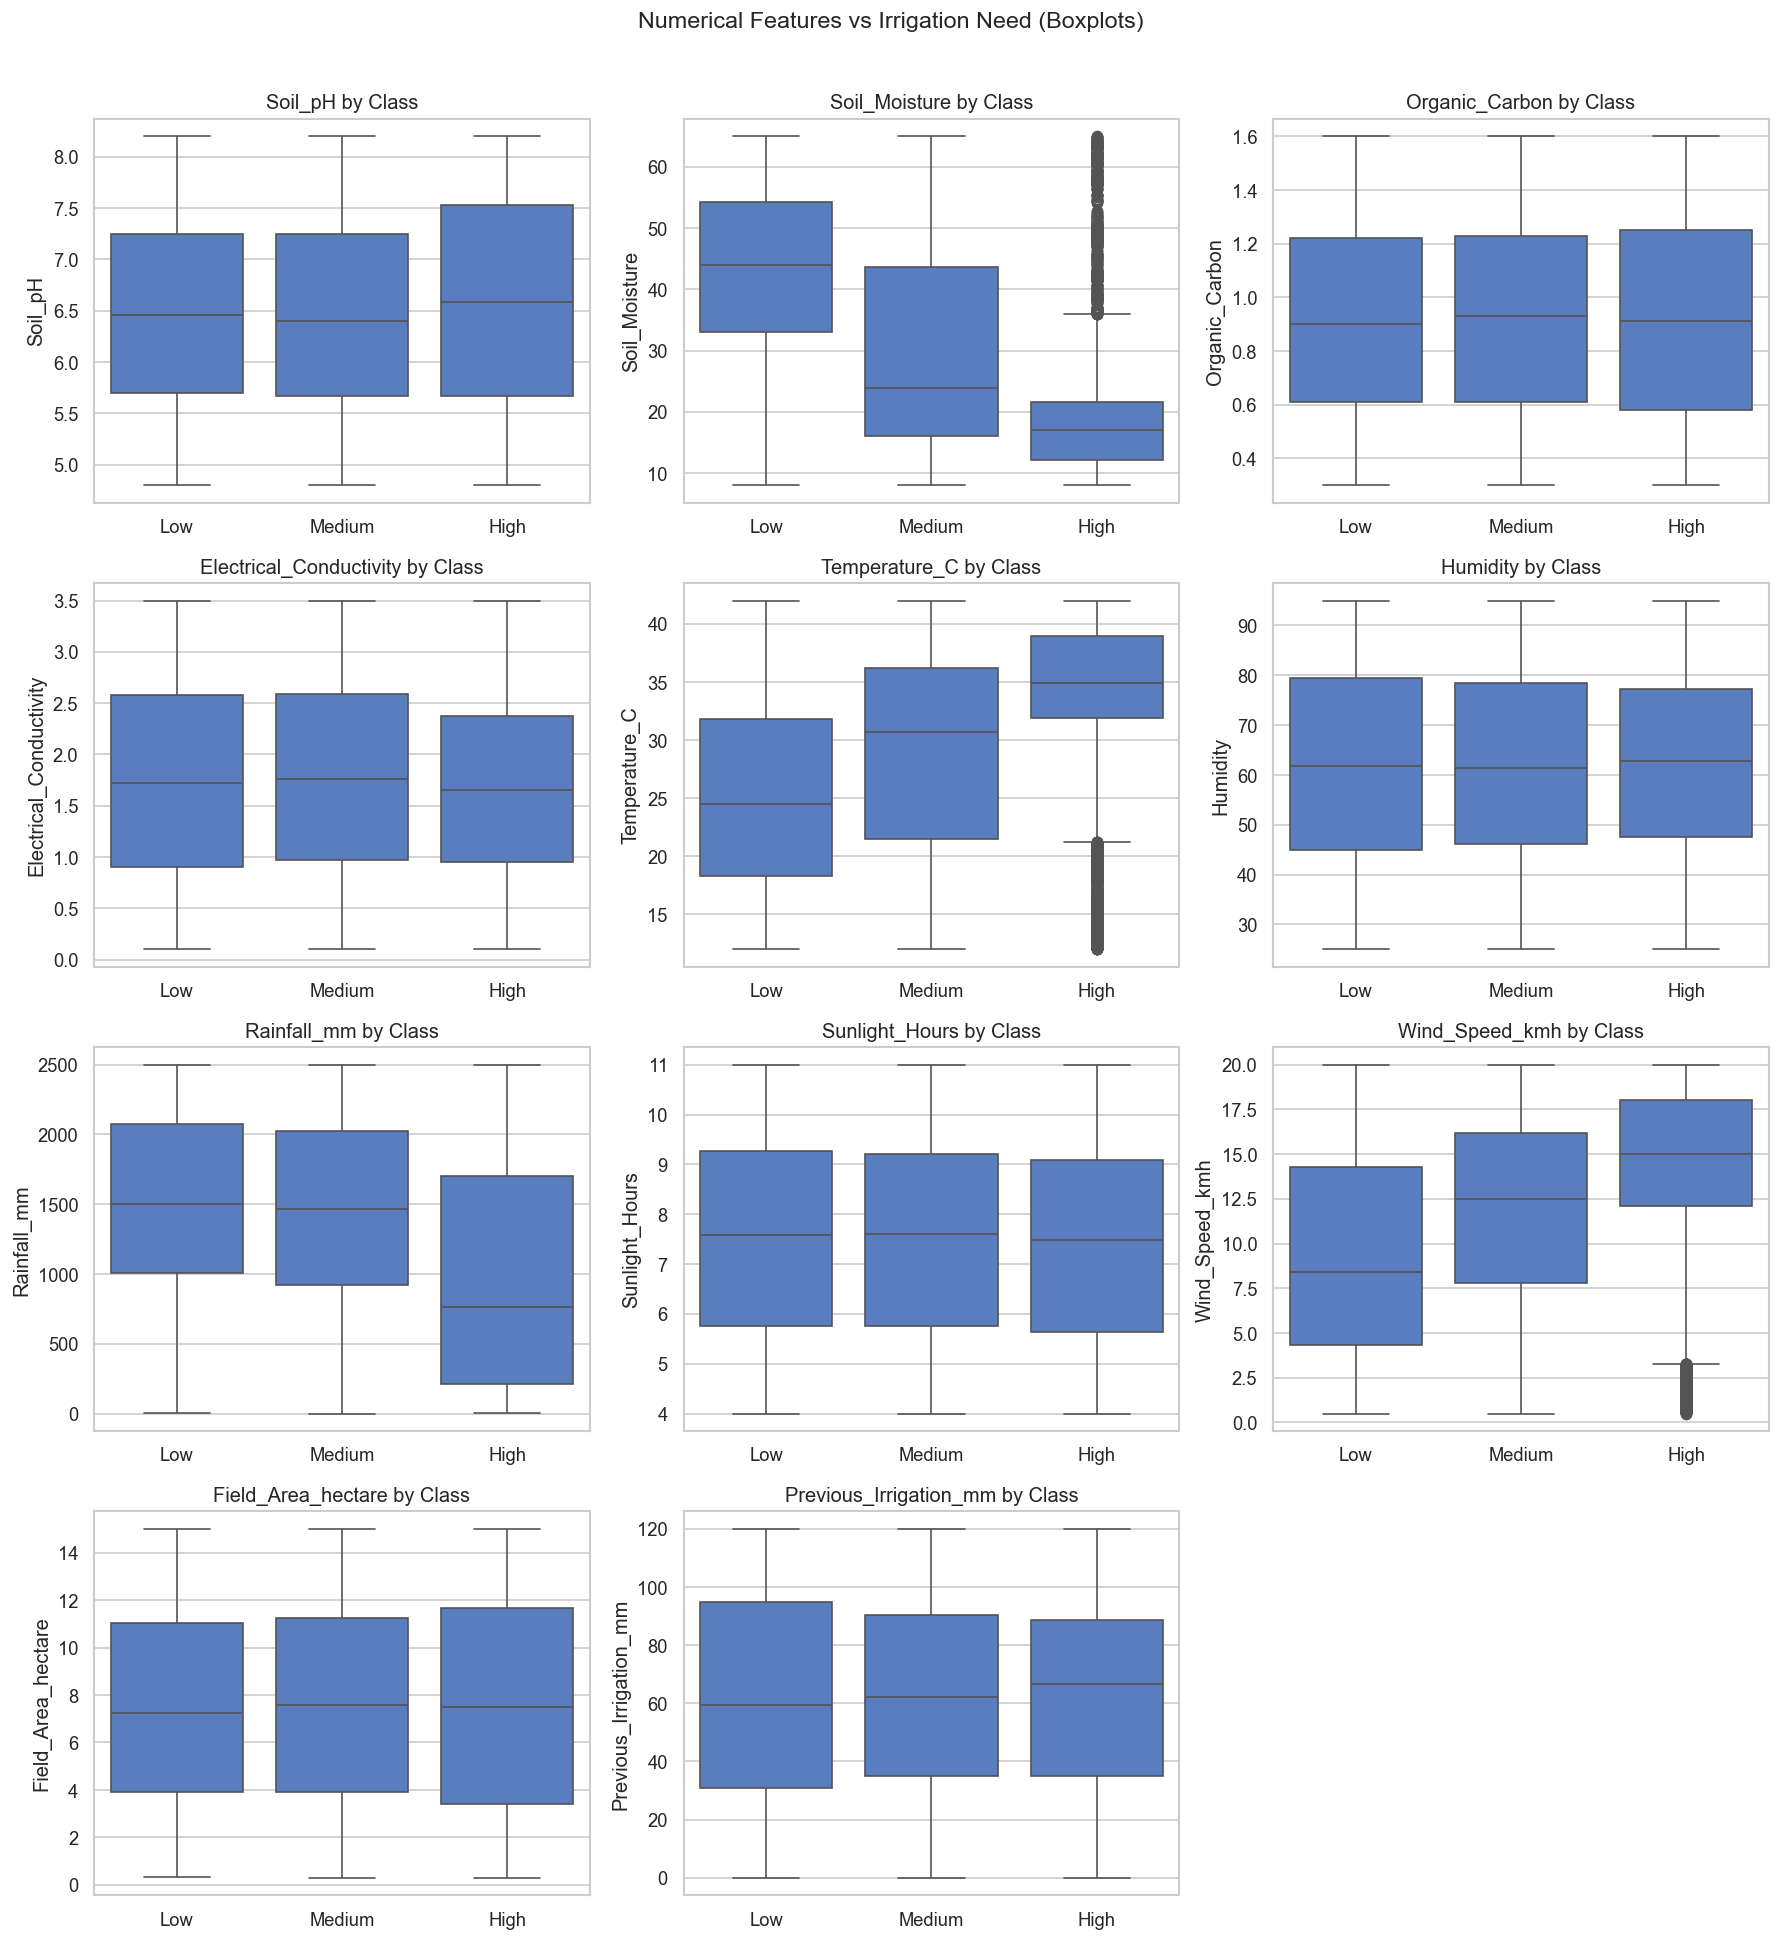

In [34]:
# Boxplots — how each numerical feature separates the classes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=train_df, x='Irrigation_Need', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Class')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features vs Irrigation Need (Boxplots)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Categorical Feature Analysis

In [35]:
# Unique value counts per categorical feature
for col in cat_cols:
    print(f'{col}: {train_df[col].nunique()} unique values → {train_df[col].unique().tolist()}')

Soil_Type: 4 unique values → ['Loamy', 'Clay', 'Sandy', 'Silt']
Crop_Type: 6 unique values → ['Sugarcane', 'Wheat', 'Rice', 'Potato', 'Cotton', 'Maize']
Crop_Growth_Stage: 4 unique values → ['Sowing', 'Vegetative', 'Flowering', 'Harvest']
Season: 3 unique values → ['Zaid', 'Kharif', 'Rabi']
Irrigation_Type: 4 unique values → ['Drip', 'Rainfed', 'Sprinkler', 'Canal']
Water_Source: 4 unique values → ['Rainwater', 'River', 'Reservoir', 'Groundwater']
Mulching_Used: 2 unique values → ['No', 'Yes']
Region: 5 unique values → ['East', 'South', 'North', 'West', 'Central']


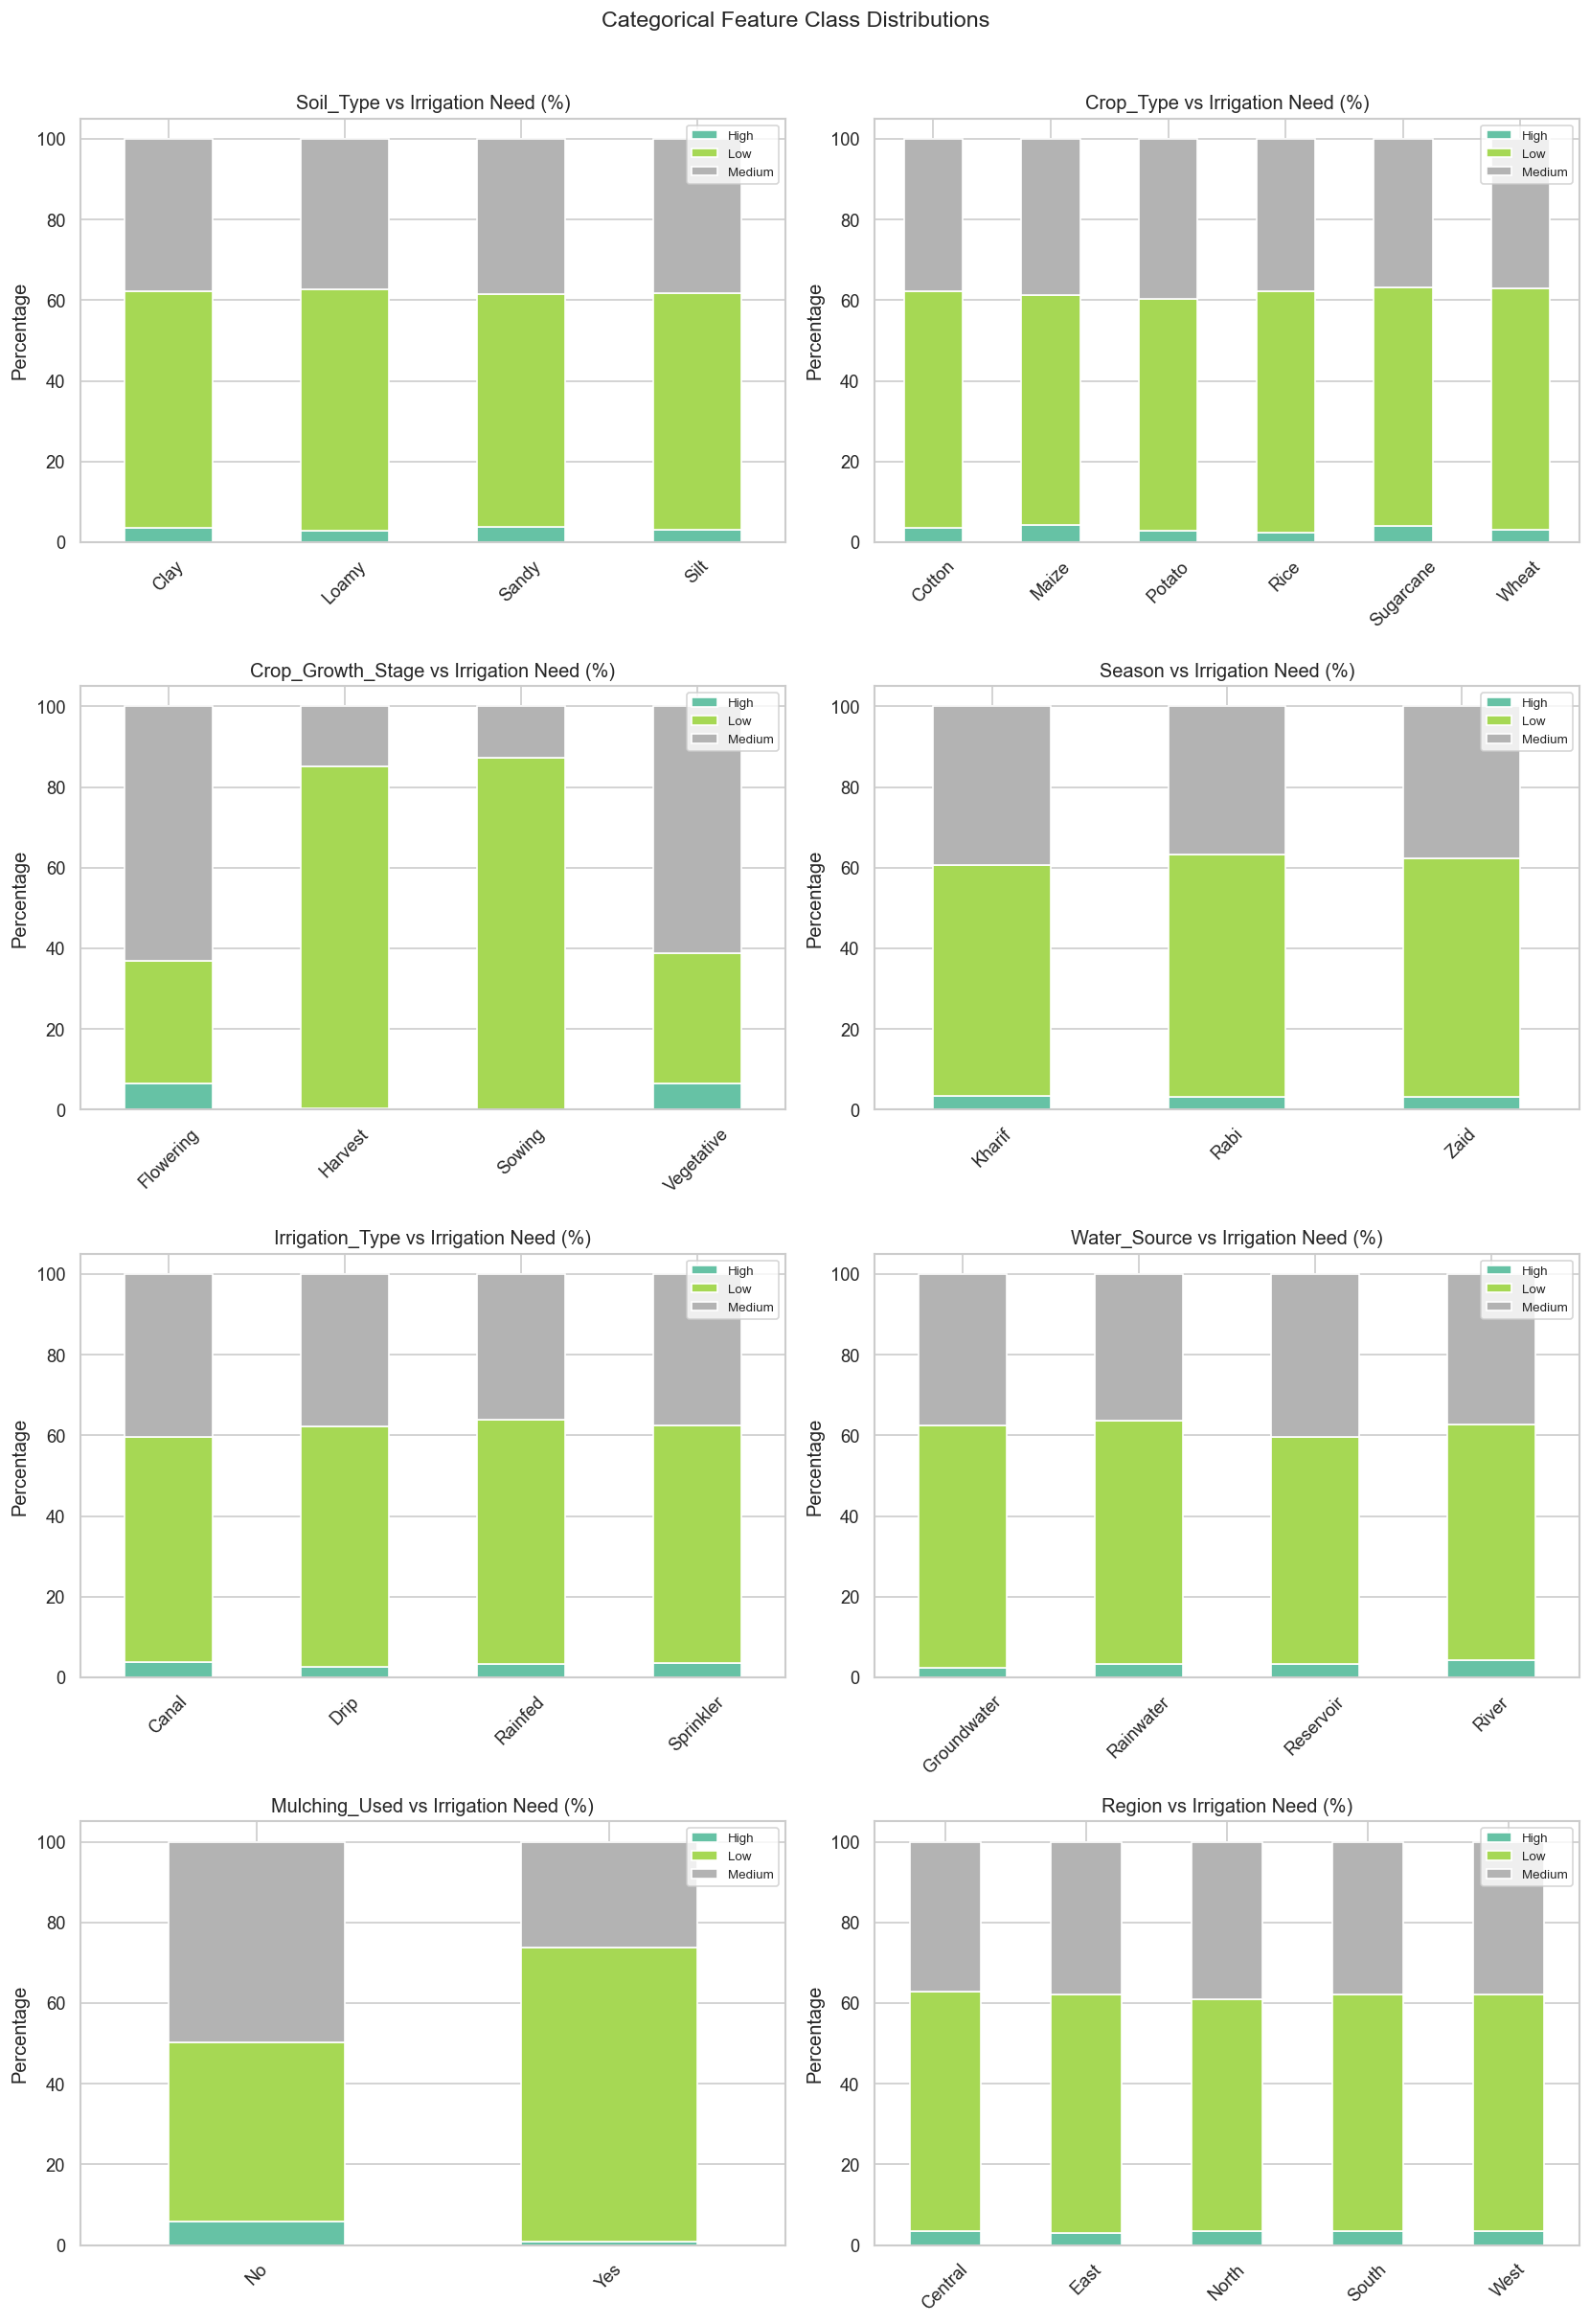

In [36]:
# Class distribution within each categorical feature
n_cols_plot = 2
n_rows_plot = int(np.ceil(len(cat_cols) / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(14, n_rows_plot * 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(train_df[col], train_df['Irrigation_Need'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2')
    axes[i].set_title(f'{col} vs Irrigation Need (%)')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Percentage')
    axes[i].legend(loc='upper right', fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Class Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Correlation Analysis — Numerical Features

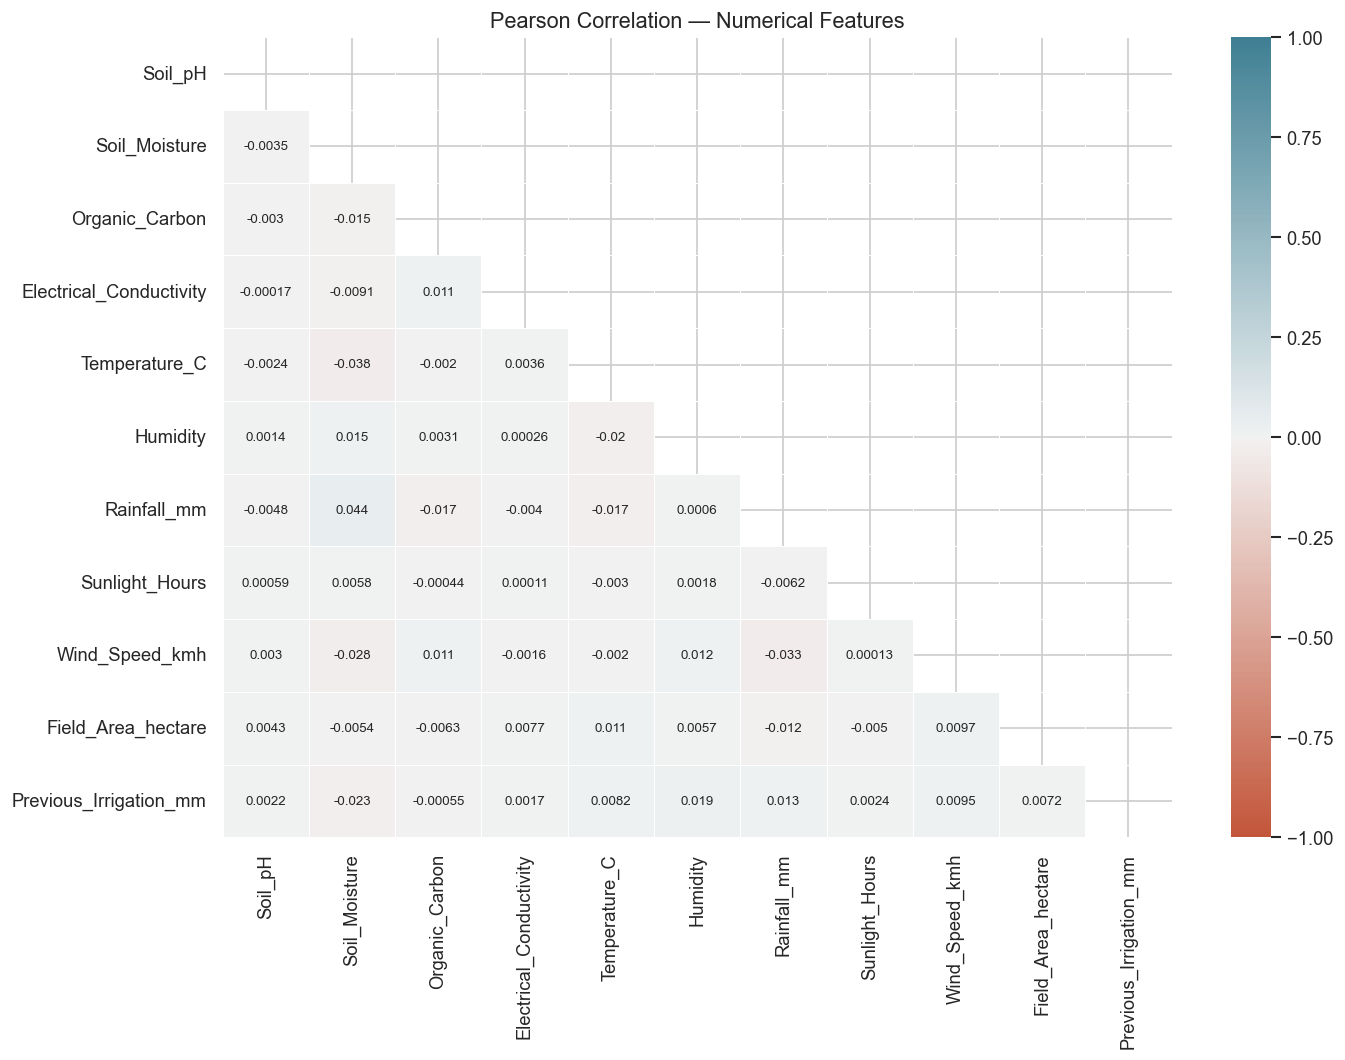

In [37]:
correlation_mat = train_df[num_cols].corr()

mask = np.zeros_like(correlation_mat)
mask[np.triu_indices_from(mask)] = True

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_mat,
    vmax=1, vmin=-1,
    annot=True,
    annot_kws={'fontsize': 8},
    mask=mask,
    cmap=sns.diverging_palette(20, 220, as_cmap=True),
    linewidths=0.5
)
plt.title('Pearson Correlation — Numerical Features', fontsize=13)
plt.tight_layout()
plt.show()

In [38]:
# Highlight highly correlated pairs (|r| > 0.7)
high_corr = (
    correlation_mat
    .abs()
    .unstack()
    .sort_values(ascending=False)
    .drop_duplicates()
)
high_corr = high_corr[(high_corr > 0.7) & (high_corr < 1.0)]

if high_corr.empty:
    print('No highly correlated numerical feature pairs found (threshold: 0.7)')
else:
    print('Highly correlated pairs (|r| > 0.7):')
    print(high_corr)

No highly correlated numerical feature pairs found (threshold: 0.7)


## 8. Mixed Correlation Analysis — Numerical + Categorical

Using `dython` associations:
- **Pearson** for numerical-numerical pairs
- **Cramér's V** for categorical-categorical pairs  
- **Correlation ratio** for numerical-categorical pairs

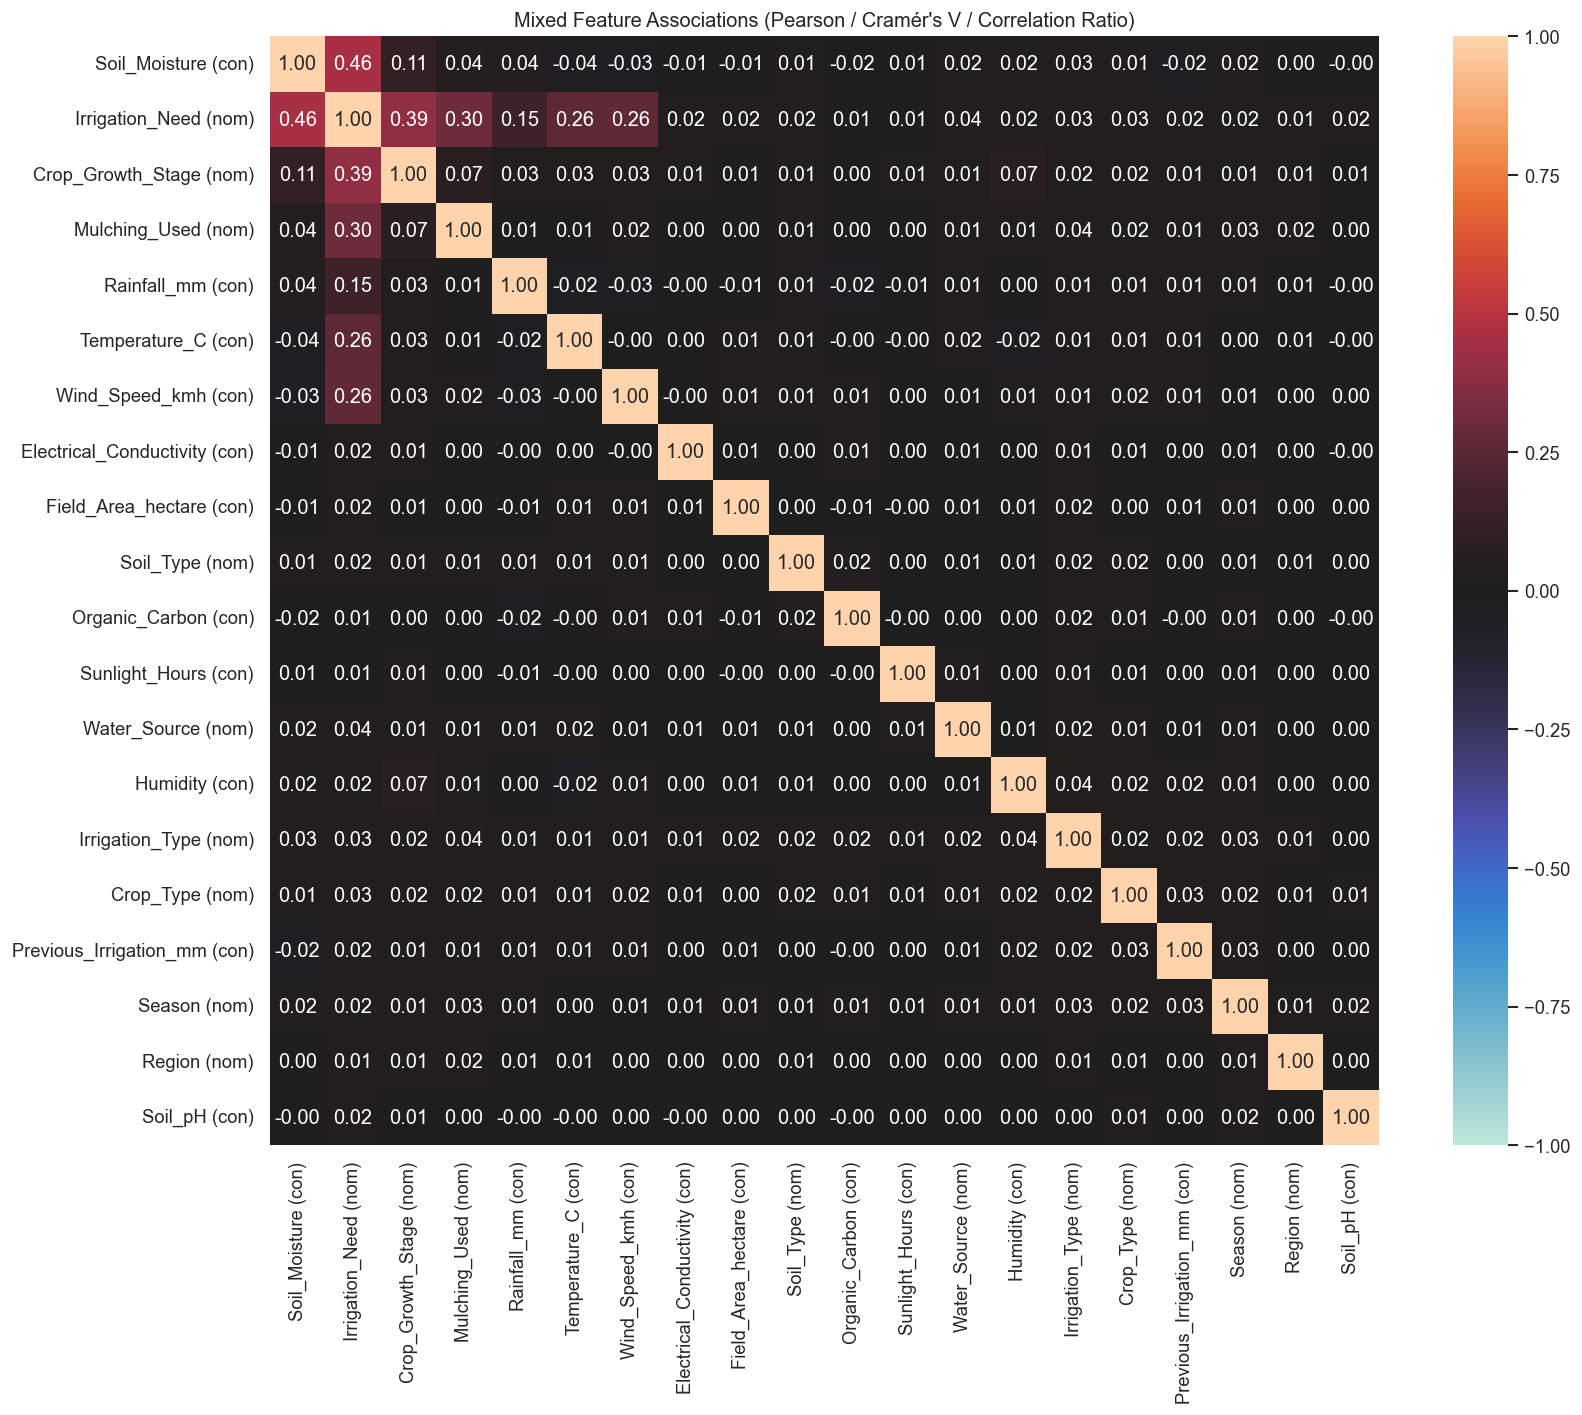

<Figure size 1200x720 with 0 Axes>

In [39]:
# Drop id before associations — it's not a feature
assoc_df = train_df.drop(columns=['id'])

associations(
    assoc_df,
    figsize=(16, 12),
    mark_columns=True,
    clustering=True,
    title='Mixed Feature Associations (Pearson / Cramér\'s V / Correlation Ratio)'
)
plt.tight_layout()
plt.show()

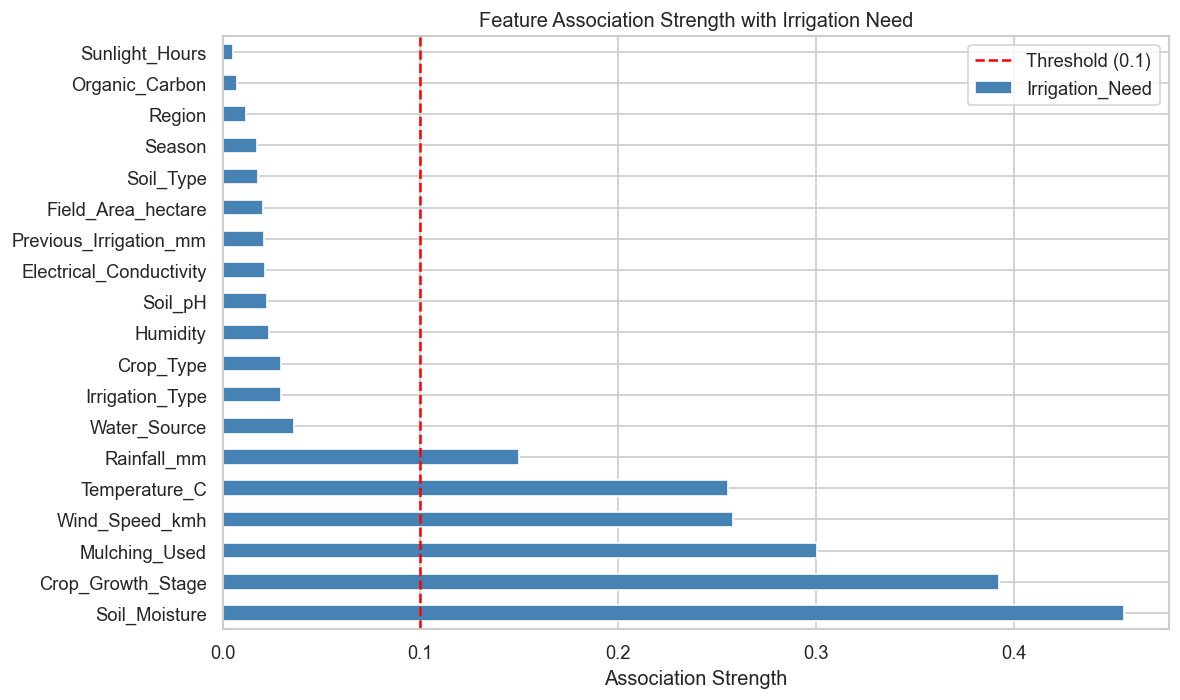

Soil_Moisture              0.455697
Crop_Growth_Stage          0.392765
Mulching_Used              0.300463
Wind_Speed_kmh             0.258275
Temperature_C              0.255741
Rainfall_mm                0.149909
Water_Source               0.036041
Irrigation_Type            0.029418
Crop_Type                  0.029344
Humidity                   0.023381
Soil_pH                    0.022412
Electrical_Conductivity    0.021594
Previous_Irrigation_mm     0.020899
Field_Area_hectare         0.020323
Soil_Type                  0.017824
Season                     0.017124
Region                     0.011969
Organic_Carbon             0.007164
Sunlight_Hours             0.005267
Name: Irrigation_Need, dtype: float64


In [40]:
# Association strength of each feature with the target
from dython.nominal import associations

assoc_result = associations(assoc_df, compute_only=True)
target_assoc = (
    assoc_result['corr']['Irrigation_Need']
    .drop('Irrigation_Need')
    .abs()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
target_assoc.plot(kind='barh', color='steelblue')
plt.title('Feature Association Strength with Irrigation Need')
plt.xlabel('Association Strength')
plt.axvline(x=0.1, color='red', linestyle='--', label='Threshold (0.1)')
plt.legend()
plt.tight_layout()
plt.show()

print(target_assoc)

## 9. Key Findings

**Class Balance:**
- [x] Classes are imbalanced

**Missing Values:**
- [x] No missing values

**Strong Predictors (high association with target):**
- [x] Soil_Moisture              
- [x] Crop_Growth_Stage
- [x] Mulching_Used 
- [x] Wind_Speed_kmh
- [x] Temperature_C
- [x] Rainfall_mm

**Highly Correlated Feature Pairs (potential redundancy):**
- [x] There are no highly correlated pairs

**Categorical Feature Observations:**
- [x] Note any categorical features that strongly separate classes

**Modeling Implications:**
- 